# K-Nearest Neighbors (KNN) 


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


## 1. Mock Data Generation

In [6]:
def generate_complex_multiclass_data(n_samples=300):
    X = np.random.randn(n_samples,6)
    y = np.zeros(n_samples, dtype=int)

    y[X[:, 0] + X[:, 1] > 0.5] = 1
    y[X[:, 2]**2 + X[:, 3] > 1.5] = 2
    
    columns = [f"Feature_{i+1}" for i in range(6)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_complex_multiclass_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Target
0,1.791855,0.941028,1.533747,-1.301107,1.912703,-0.537121,1
1,-0.060664,-0.502418,-0.202845,0.777911,-0.940387,1.094480,0
2,-0.197723,1.500753,-1.031486,-1.249793,1.121874,-0.361439,1
3,-0.963450,0.139353,0.422082,-1.326331,-0.381273,0.388083,0
4,-0.222058,-0.344390,0.287290,-1.270595,1.226515,-1.038827,0


## 2.Implementation

In [7]:
class KNNClassifierScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

## 3. Training and Visualization

Accuracy: 89.00%


C:\Users\lenovo\AppData\Local\Temp\ipykernel_19356\1460400874.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette='magma')


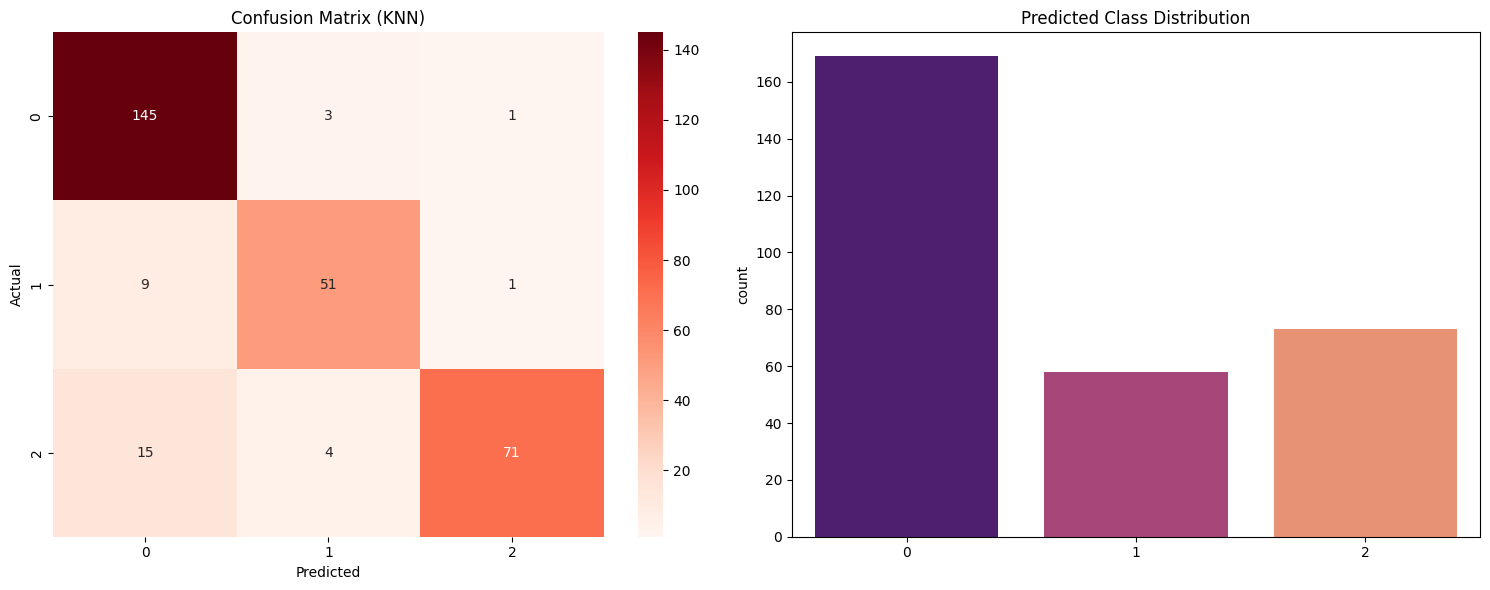

In [8]:
model = KNNClassifierScratch(k=5)
model.fit(X, y)

y_pred = model.predict(X)
print(f"Accuracy: {np.mean(y == y_pred) * 100:.2f}%")

plt.figure(figsize=(15, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
matrix = pd.crosstab(results_df['Actual'], results_df['Predicted'])
sns.heatmap(matrix, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix (KNN)")

# 2. Class Distribution Prediction
plt.subplot(1, 2, 2)
sns.countplot(x=y_pred, palette='magma')
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()